<a href="https://colab.research.google.com/github/gleis7/my-app/blob/main/kronos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kronos Deployment
Cloning the repository from `https://github.com/shiyu-coder/Kronos`.

In [ ]:
!git clone https://github.com/shiyu-coder/Kronos.git
%cd Kronos

Cloning into 'Kronos'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 371 (delta 103), reused 91 (delta 91), pack-reused 222 (from 1)
Receiving objects: 100% (371/371), 9.30 MiB | 24.54 MiB/s, done.
Resolving deltas: 100% (185/185), done.
/content/Kronos


Next, we should check for a `requirements.txt` or setup script to install dependencies.

In [ ]:
!ls -F

examples/  finetune/	  LICENSE  README.md	     tests/
figures/   finetune_csv/  model/   requirements.txt  webui/


## 1. Install Dependencies
Installing the required Python packages from `requirements.txt`.

In [ ]:
!pip install -r requirements.txt

## 2. Verify Model Assets
Checking the `model/` directory for pre-trained weights.

In [ ]:
!ls -F model/

__init__.py  kronos.py	module.py


/content/Kronos
Generating prediction...


100%|██████████| 120/120 [05:02<00:00,  2.52s/it]


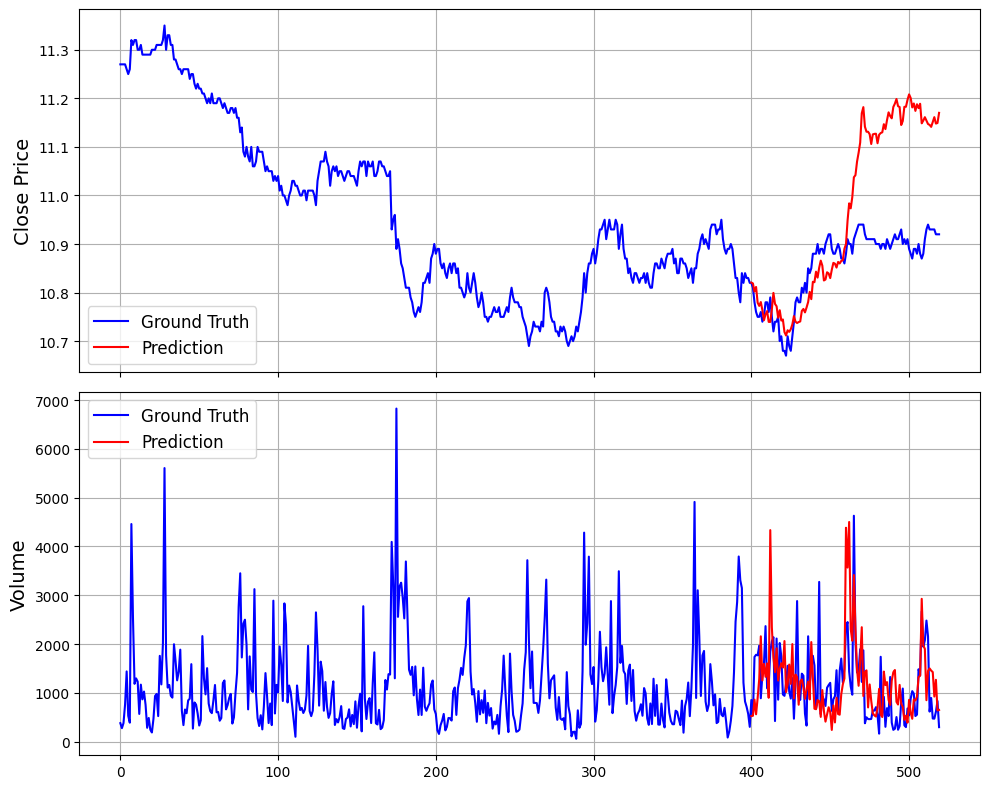

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Ensure we are in the project directory
%cd /content/Kronos
sys.path.append(os.getcwd())

from model import Kronos, KronosTokenizer, KronosPredictor

def plot_prediction(kline_df, pred_df):
    pred_df.index = kline_df.index[-pred_df.shape[0]:]
    sr_close = kline_df['close']
    sr_pred_close = pred_df['close']
    sr_close.name = 'Ground Truth'
    sr_pred_close.name = "Prediction"

    sr_volume = kline_df['volume']
    sr_pred_volume = pred_df['volume']
    sr_volume.name = 'Ground Truth'
    sr_pred_volume.name = "Prediction"

    close_df = pd.concat([sr_close, sr_pred_close], axis=1)
    volume_df = pd.concat([sr_volume, sr_pred_volume], axis=1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    ax1.plot(close_df['Ground Truth'], label='Ground Truth', color='blue', linewidth=1.5)
    ax1.plot(close_df['Prediction'], label='Prediction', color='red', linewidth=1.5)
    ax1.set_ylabel('Close Price', fontsize=14)
    ax1.legend(loc='lower left', fontsize=12)
    ax1.grid(True)

    ax2.plot(volume_df['Ground Truth'], label='Ground Truth', color='blue', linewidth=1.5)
    ax2.plot(volume_df['Prediction'], label='Prediction', color='red', linewidth=1.5)
    ax2.set_ylabel('Volume', fontsize=14)
    ax2.legend(loc='upper left', fontsize=12)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# 1. Load Model and Tokenizer
tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
model = Kronos.from_pretrained("NeoQuasar/Kronos-base")

# 2. Instantiate Predictor
predictor = KronosPredictor(model, tokenizer, max_context=512)

# 3. Prepare Data
df = pd.read_csv("./data/XSHG_5min_600977.csv")
df['timestamps'] = pd.to_datetime(df['timestamps'])

lookback = 400
pred_len = 120

x_df = df.loc[:lookback-1, ['open', 'high', 'low', 'close', 'volume', 'amount']]
x_timestamp = df.loc[:lookback-1, 'timestamps']
y_timestamp = df.loc[lookback:lookback+pred_len-1, 'timestamps']

# 4. Make Prediction
print("Generating prediction...")
pred_df = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=y_timestamp,
    pred_len=pred_len,
    T=1.0,
    top_p=0.9,
    sample_count=1,
    verbose=True
)

# 5. Visualize Results
kline_df = df.loc[:lookback+pred_len-1]
plot_prediction(kline_df, pred_df)

own data

Generating prediction for ./data/600362_512_days.csv...


100%|██████████| 100/100 [04:02<00:00,  2.43s/it]


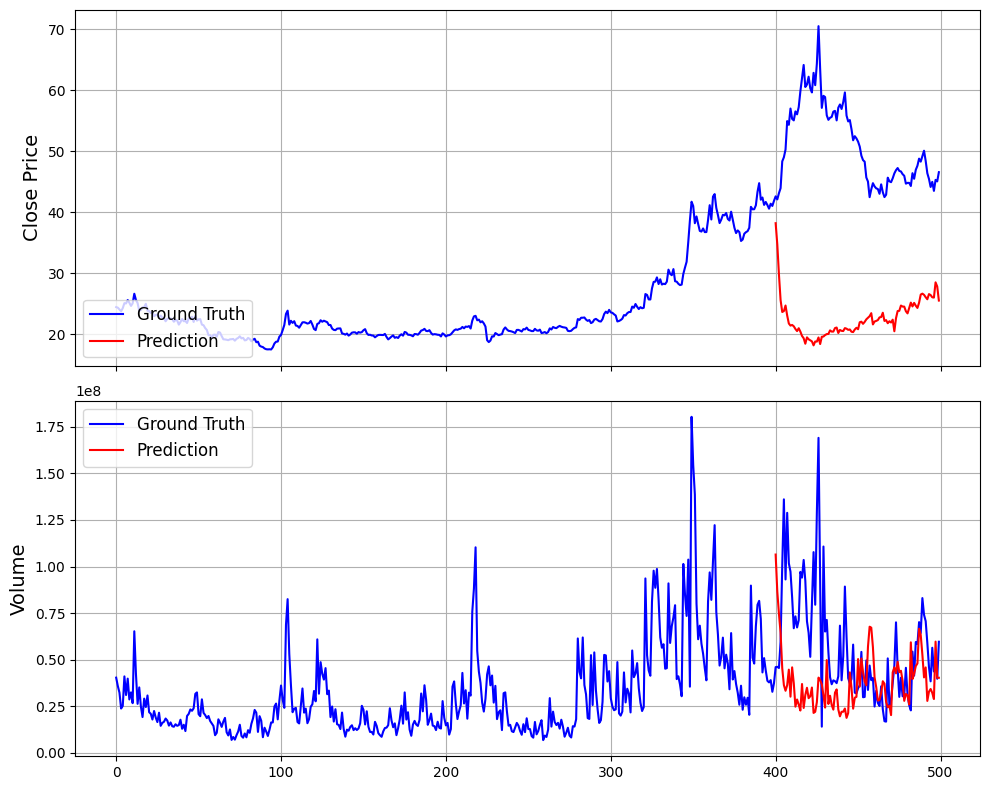

In [ ]:
# Load the new dataset
new_data_path = "./data/600362_512_days.csv"
# Some files might be in the examples folder based on the file list
if not os.path.exists(new_data_path):
    new_data_path = "./examples/600362_512_days.csv"

df_new = pd.read_csv(new_data_path)
# Standardize column naming if necessary (assuming it follows the same format)
df_new['timestamps'] = pd.to_datetime(df_new['date'] if 'date' in df_new.columns else df_new['timestamps'])

# Define parameters
lookback = 400
pred_len = 100 # Adjusting pred_len slightly for this dataset

# Slicing the data
x_df_new = df_new.iloc[-(lookback + pred_len):-pred_len].reset_index(drop=True)
x_timestamp_new = x_df_new['timestamps']
# We use the actual future timestamps from the file as ground truth targets if available
y_timestamp_new = df_new['timestamps'].iloc[-pred_len:].reset_index(drop=True)

print(f"Generating prediction for {new_data_path}...")
pred_df_new = predictor.predict(
    df=x_df_new[['open', 'high', 'low', 'close', 'volume', 'amount']],
    x_timestamp=x_timestamp_new,
    y_timestamp=y_timestamp_new,
    pred_len=pred_len,
    T=1.0,
    top_p=0.9,
    sample_count=1,
    verbose=True
)

# Plotting using the function defined earlier
kline_df_new = df_new.iloc[-(lookback + pred_len):].reset_index(drop=True)
plot_prediction(kline_df_new, pred_df_new)